In [28]:
#%pip install pandas==2.2.3
#%pip install git+https://github.com/pydata/pandas-datareader.git
#%pip install yfinance numpy matplotlib
#%pip install shap
#%pip install lime

In [29]:
import pandas as pd #Importamos pandas para el manejo de dataframes y series temporales
import numpy as np #Importamos numpy para el manejo de arrays y operaciones matemáticas
import matplotlib.pyplot as plt #Importamos matplotlib para la visualización de datos       
from sklearn.ensemble import RandomForestRegressor #Importamos RandomForestRegressor para la selección de variables y la construcción del modelo de machine learning
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit #Importamos GridSearchCV para la búsqueda de hiperparámetros y TimeSeriesSplit para la validación cruzada en series temporales
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, make_scorer #Importamos mean_absolute_error, mean_squared_error y r2_score para la evaluación del rendimiento del modelo de machine learning
import joblib #Importamos joblib para guardar y cargar modelos de machine learning entrenados
from sklearn.preprocessing import QuantileTransformer #Importamos QuantileTransformer para la transformación de variables numéricas
from sklearn.isotonic import IsotonicRegression #Importamos IsotonicRegression para realizar regresión isotónica, que es una técnica de ajuste de curvas monotónicas
import shap
import lime
import lime.lime_tabular

In [30]:
df = pd.read_csv('../../dataset_ml.csv') 
print(df.head())

#df.drop(columns=['Date'], inplace=True) #Eliminamos la columna 'Date' ya que no es una característica numérica y no aporta información relevante para el modelo. Además, eliminamos la columna 'target' ya que es la variable que queremos predecir.

   oro_return    precio  inflacion_usa  volatilidad_6m     lag_3  tipos_ecb  \
0    0.047631  0.320155       0.020352        0.088742 -0.083592        1.0   
1   -0.032475  0.337983       0.020263        0.081350  0.104730        1.0   
2    0.022960  0.358358       0.016885        0.079723 -0.086500        1.0   
3    0.038561  0.405100       0.017401        0.076144  0.021998        1.0   
4   -0.094313  0.386223       0.022926        0.078530  0.055686        1.0   

     eurusd  activo_return  desempleo  sp500_return  ...  inflacion_usa_lag1  \
0  1.259002       0.021998        5.7      0.050766  ...            0.020348   
1  1.245206       0.055686        5.7      0.017276  ...            0.020352   
2  1.253007       0.060284        5.6      0.012209  ...            0.020263   
3  1.231300       0.130434        5.8     -0.016359  ...            0.016885   
4  1.198294      -0.046598        5.6     -0.016791  ...            0.017401   

   inflacion_usa_lag3  inflacion_usa_lag6   

In [31]:
X = df.drop(columns=['target']) #Separamos las características (X) de la variable objetivo (Y) para preparar los datos para el entrenamiento del modelo de machine learning.
Y = df['target']

In [32]:
def division_conjuntos(dataframe, tr_size=0.8, vl_size=0.1, ts_size=0.1 ):
    '''Función para dividir un dataframe en conjuntos de entrenamiento, validación y prueba.
    Parámetros:
    dataframe: DataFrame a dividir
    tr_size: Proporción de datos para el conjunto de entrenamiento (default=0.8)
    vl_size: Proporción de datos para el conjunto de validación (default=0.1)
    ts_size: Proporción de datos para el conjunto de prueba (default=0.1)
    Retorna:
    train: DataFrame de entrenamiento
    val: DataFrame de validación
    test: DataFrame de prueba
    '''
    N = dataframe.shape[0] # Número total de datos
    Ntrain = int(tr_size*N)  # Número de datos de entrenamiento
    Nval = int(vl_size*N)    # Número de datos de validación
    Ntst = int(ts_size*N)    # Número de datos de prueba

    # Realizar partición
    train = dataframe[0:Ntrain] # Conjunto de entrenamiento
    val = dataframe[Ntrain:Ntrain+Nval] # Conjunto de validación
    test = dataframe[Ntrain+Nval:] # Conjunto de prueba

    return train, val, test

# Prueba de la función
tr, vl, ts = division_conjuntos(df) # Dividimos el dataframe en conjuntos de entrenamiento, validación y prueba utilizando la función division_conjuntos.

X_train = tr.drop(columns=['target']) # Separamos las características (X) de la variable objetivo (Y) para el conjunto de entrenamiento, eliminando la columna 'target' que es la variable que queremos predecir.
y_train = tr['target']

X_val = vl.drop(columns=['target']) # Separamos las características (X) de la variable objetivo (Y) para el conjunto de validación, eliminando la columna 'target' que es la variable que queremos predecir.
y_val = vl['target']

X_test = ts.drop(columns=['target']) # Separamos las características (X) de la variable objetivo (Y) para el conjunto de prueba, eliminando la columna 'target' que es la variable que queremos predecir.
y_test = ts['target']

print(f'Entrenamiento: {X_train.shape}')
print(f'Validación: {X_val.shape}')
print(f'Prueba: {X_test.shape}')

Entrenamiento: (212, 26)
Validación: (26, 26)
Prueba: (27, 26)


In [33]:
def directional_accuracy(y_true, y_pred):
    true_dir = np.sign(y_true)
    pred_dir = np.sign(y_pred)
    valid = true_dir != 0
    if valid.sum() == 0:
        return 0
    return np.mean(true_dir[valid] == pred_dir[valid])

# Creamos el scorer para GridSearch
da_scorer = make_scorer(directional_accuracy, greater_is_better=True)

In [34]:

param_grid_rf = {
    'n_estimators': [100, 200, 300], #Número de árboles en el bosque
    'max_depth': [5, 10, 15, 20, None], #Profundidad máxima de los árboles.
    'min_samples_split': [2, 5, 10, 12], #Número mínimo de muestras requeridas para dividir un nodo interno.
    'min_samples_leaf': [1, 2 ,4], #Número mínimo de muestras requeridas para estar en un nodo hoja.
    'max_features': ['sqrt', 'log2', None] #Número de características a considerar para encontrar la mejor división en cada nodo.
} #Definimos una cuadrícula de hiperparámetros para el modelo de Random Forest,

ts_cv = TimeSeriesSplit(n_splits=3) #Definimos una estrategia de validación cruzada para series temporales utilizando TimeSeriesSplit, que divide los datos en conjuntos de entrenamiento y validación respetando el orden temporal de los datos.

# Inicializar el modelo
rf = RandomForestRegressor(random_state=42, n_jobs=-1) #Inicializamos el modelo de Random Forest Regressor con un estado aleatorio fijo para reproducibilidad y utilizando todos los núcleos disponibles para acelerar el entrenamiento.

grid_search_rf = GridSearchCV(
    estimator=rf,
    param_grid=param_grid_rf,
    cv=ts_cv,
    scoring=da_scorer,
    verbose=1,
    n_jobs=-1
)  # Configuramos la búsqueda de hiperparámetros utilizando GridSearchCV, especificando el modelo, la cuadrícula de hiperparámetros, la estrategia de validación cruzada, la métrica de evaluación, y habilitando la salida detallada y el uso de múltiples núcleos para acelerar el proceso.

# Ajustar la búsqueda
grid_search_rf.fit(X_train, y_train) #Ejecutamos la búsqueda de hiperparámetros ajustando el modelo a los datos de entrenamiento utilizando la configuración definida en GridSearchCV.


print(f"Mejores hiperparámetros: {grid_search_rf.best_params_}")
print(f"Mejor MAE: {-grid_search_rf.best_score_:.4f}")

Fitting 3 folds for each of 540 candidates, totalling 1620 fits
Mejores hiperparámetros: {'max_depth': 10, 'max_features': None, 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 200}
Mejor MAE: -0.6352


In [ ]:
best_rf = RandomForestRegressor(**grid_search_rf.best_params_, random_state=42, n_jobs=-1) #Creamos un nuevo modelo de Random Forest Regressor utilizando los mejores hiperparámetros encontrados en la búsqueda.
best_rf.fit(X_train, y_train) #Entrenamos el modelo de Random Forest Regressor con los mejores hiperparámetros utilizando los datos de entrenamiento.

y_pred_val_raw = best_rf.predict(X_val) #Realizamos predicciones utilizando el modelo entrenado en el conjunto de validación para evaluar su rendimiento antes de probarlo en el conjunto de prueba.

calibrator_rf = IsotonicRegression(out_of_bounds='clip')
calibrator_rf.fit(y_pred_val_raw, y_val)

# Calibrar predicciones de test
y_pred_test_raw = best_rf.predict(X_test)
y_pred_test_calibrated = calibrator_rf.predict(y_pred_test_raw)

# Ver efecto de la calibración
print(f"Media real (test): {y_test.mean():.4f}")
print(f"Media predicción original: {y_pred_test_raw.mean():.4f}")
print(f"Media predicción calibrada: {y_pred_test_calibrated.mean():.4f}")

r2_original = r2_score(y_test, y_pred_test_raw)
r2_calibrado = r2_score(y_test, y_pred_test_calibrated)

print(f"\nR² original: {r2_original:.4f}")
print(f"R² calibrado: {r2_calibrado:.4f}")

# Decidir cuál usar
if r2_calibrado > r2_original:
    print("\nUsando predicciones CALIBRADAS (mejor R²)")
    y_pred_test = y_pred_test_calibrated
else:
    print("\nUsando predicciones ORIGINALES")
    y_pred_test = y_pred_test_raw

y_pred_val = calibrator_rf.predict(y_pred_val_raw) if r2_calibrado > r2_original else y_pred_val_raw

# Métricas de validación
mae_val = mean_absolute_error(y_val, y_pred_val) #Calculamos el error absoluto medio (MAE) entre las predicciones del modelo y los valores reales en el conjunto de validación para evaluar la precisión del modelo.
rmse_val = np.sqrt(mean_squared_error(y_val, y_pred_val)) #Calculamos la raíz del error cuadrático medio (RMSE) entre las predicciones del modelo y los valores reales en el conjunto de validación para evaluar la precisión del modelo, penalizando más los errores grandes.
r2_val = r2_score(y_val, y_pred_val)
da_val = directional_accuracy(y_val, y_pred_val)

print(f"MAE: {mae_val:.4f}")
print(f"RMSE: {rmse_val:.4f}")
print(f"R²: {r2_val:.4f}")
print(f"Directional Accuracy: {da_val:.4f}")

Media real (test): 0.0186
Media predicción original: 0.0166
Media predicción calibrada: 0.0084

R² original: -0.0001
R² calibrado: -0.0316

⚠️ Usando predicciones ORIGINALES
MAE: 0.0888
RMSE: 0.1122
R²: -0.8597
Directional Accuracy: 0.5000


MAE: 0.0741
RMSE: 0.0888
R²: -0.1660
Directional Accuracy: 0.4615

In [36]:
# Evaluación en el conjunto de prueba

y_pred_test = best_rf.predict(X_test)

mae_test = mean_absolute_error(y_test, y_pred_test)
rmse_test = np.sqrt(mean_squared_error(y_test, y_pred_test))
r2_test = r2_score(y_test, y_pred_test)
da_test = directional_accuracy(y_test, y_pred_test)

print(f"MAE: {mae_test:.4f}")
print(f"RMSE: {rmse_test:.4f}")
print(f"R²: {r2_test:.4f}")
print(f"Directional Accuracy: {da_test:.4f}")

MAE: 0.0477
RMSE: 0.0579
R²: -0.0001
Directional Accuracy: 0.5926


MAE: 0.0477
RMSE: 0.0579
R²: -0.0001
Directional Accuracy: 0.5926

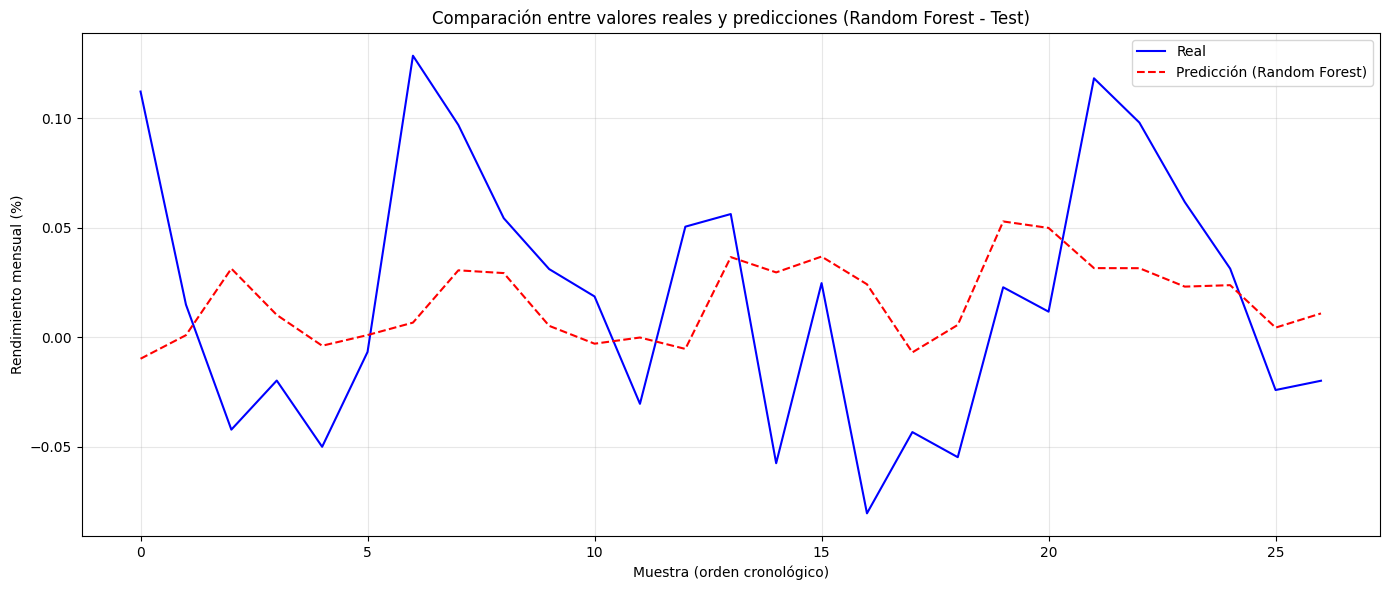

In [37]:
plt.figure(figsize=(14, 6))

# Ordenar por índice (asegurar orden cronológico)
indices = range(len(y_test))

plt.plot(indices, y_test.values, label='Real', color='blue', linewidth=1.5)
plt.plot(indices, y_pred_test, label='Predicción (Random Forest)', color='red', linestyle='--', linewidth=1.5)

plt.title('Comparación entre valores reales y predicciones (Random Forest - Test)')
plt.xlabel('Muestra (orden cronológico)')
plt.ylabel('Rendimiento mensual (%)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()



In [38]:
def backtesting_rf(dataframe, window_train=180, test_size=12, step=12, best_params=None):
    """
    Realiza backtesting con ventana deslizante para Random Forest.
    
    Parámetros:
    -----------
    dataframe : DataFrame
        Dataset completo ordenado cronológicamente
    window_train : int
        Tamaño de la ventana de entrenamiento (meses)
    test_size : int
        Tamaño de la ventana de prueba (meses)
    step : int
        Número de meses que se desplaza la ventana en cada iteración
    best_params : dict
        Mejores hiperparámetros encontrados en la búsqueda previa
        
    Retorna:
    --------
    resultados : DataFrame
        DataFrame con las métricas de cada iteración
    media_metricas : dict
        Diccionario con las métricas promedio
    """
    
    resultados = []
    
    if best_params is None:
        best_params = {
            'n_estimators': 200,
            'max_depth': 15,
            'min_samples_split': 5,
            'min_samples_leaf': 2,
            'max_features': 'sqrt',
            'random_state': 42,
            'n_jobs': -1
        } # Si no se proporcionan mejores hiperparámetros, se usan valores por defecto
    
    # Calcular número total de iteraciones
    n_iterations = (len(dataframe) - window_train - test_size) // step + 1 # Calculamos el número total de iteraciones que se realizarán en el backtesting, teniendo en cuenta el tamaño de la ventana de entrenamiento, el tamaño de la ventana de prueba y el paso de desplazamiento.
    
    for i, start in enumerate(range(0, len(dataframe) - window_train - test_size, step)): # Iteramos sobre el rango de índices para crear las ventanas de entrenamiento y prueba, desplazando la ventana en cada iteración según el paso definido.
        
        train_end = start + window_train
        test_end = train_end + test_size
        
        # Obtenemos los datos de entrenamiento y prueba
        train = dataframe.iloc[start:train_end]
        test = dataframe.iloc[train_end:test_end]
        
        # Separamos características (X) y variable objetivo (y)
        X_train = train.drop(columns=['target'])
        y_train = train['target']
        
        X_test = test.drop(columns=['target'])
        y_test = test['target']
        
        # Creamos y entrenamos el modelo con los mejores hiperparámetros
        rf = RandomForestRegressor(**best_params)
        rf.fit(X_train, y_train)
        
        # Realizamos predicciones
        y_pred = rf.predict(X_test)
        
        # Calculamos métricas
        mae = mean_absolute_error(y_test, y_pred)
        rmse = np.sqrt(mean_squared_error(y_test, y_pred))
        r2 = r2_score(y_test, y_pred)
        
        if isinstance(dataframe.index, pd.RangeIndex): # Información de las fechas (si el índice es numérico, mostrar rangos)
            periodo_train = f"[{start}:{train_end-1}]"
            periodo_test = f"[{train_end}:{test_end-1}]"
        else: # Información de las fechas (si el índice es de tipo fecha, mostrar rangos de fechas)
            periodo_train = f"{train.index[0]} - {train.index[-1]}"
            periodo_test = f"{test.index[0]} - {test.index[-1]}"
        
        resultados.append({
            'iteracion': i + 1,
            'train_inicio': start,
            'train_fin': train_end - 1,
            'test_inicio': train_end,
            'test_fin': test_end - 1,
            'MAE': mae,
            'RMSE': rmse,
            'R2': r2,
            'Da': directional_accuracy(y_test, y_pred)
        }) # Guardamos los resultados de cada iteración en una lista de diccionarios, donde cada diccionario contiene la información de la iteración, los índices de las ventanas de entrenamiento y prueba, y las métricas calculadas (MAE, RMSE, R²).
            
    df_resultados = pd.DataFrame(resultados) # Convertimos la lista de resultados a un DataFrame para facilitar el análisis y la visualización de las métricas obtenidas en cada iteración del backtesting.
    
    media_metricas = {
        'MAE_mean': df_resultados['MAE'].mean(),
        'MAE_std': df_resultados['MAE'].std(),
        'RMSE_mean': df_resultados['RMSE'].mean(),
        'RMSE_std': df_resultados['RMSE'].std(),
        'R2_mean': df_resultados['R2'].mean(),
        'R2_std': df_resultados['R2'].std(),
        'Da_mean': df_resultados['Da'].mean(),
        'Da_std': df_resultados['Da'].std()    
    } # Calculamos las métricas promedio y su desviación estándar para cada métrica (MAE, RMSE, R²) a partir de los resultados obtenidos en cada iteración del backtesting.
    
    
    print(f"MAE medio: {media_metricas['MAE_mean']:.4f} (±{media_metricas['MAE_std']:.4f})")
    print(f"RMSE medio: {media_metricas['RMSE_mean']:.4f} (±{media_metricas['RMSE_std']:.4f})")
    print(f"R² medio: {media_metricas['R2_mean']:.4f} (±{media_metricas['R2_std']:.4f})")
    print(f"Directional Accuracy media: {media_metricas['Da_mean']:.4f} (±{media_metricas['Da_std']:.4f})")
    
    return df_resultados, media_metricas

In [39]:
best_params_rf = grid_search_rf.best_params_
best_params_rf['random_state'] = 42
best_params_rf['n_jobs'] = -1

# Ejecutamos backtesting
resultados_backtest, metricas_backtest = backtesting_rf(
    dataframe=df,
    window_train=220,  # 200 meses de entrenamiento (~16.7 años)
    test_size=12,      # 24 meses de prueba (~2 años)
    step=22,           # Desplazar la ventana 12 meses cada iteración
    best_params=best_params_rf
)

MAE medio: 0.0663 (±0.0355)
RMSE medio: 0.0786 (±0.0377)
R² medio: -0.0399 (±0.1664)
Directional Accuracy media: 0.5833 (±0.3536)


MAE medio: 0.0663 (±0.0355)
RMSE medio: 0.0786 (±0.0377)
R² medio: -0.0399 (±0.1664)
Directional Accuracy media: 0.5833 (±0.3536)

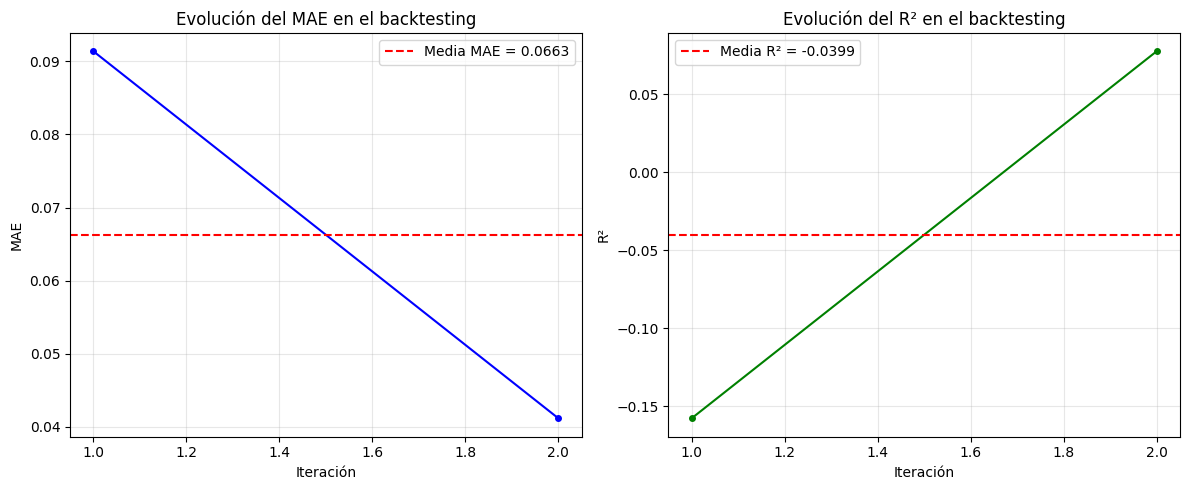

In [40]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(resultados_backtest['iteracion'], resultados_backtest['MAE'], 'o-', color='blue', markersize=4)
plt.axhline(y=metricas_backtest['MAE_mean'], color='red', linestyle='--', label=f'Media MAE = {metricas_backtest["MAE_mean"]:.4f}')
plt.xlabel('Iteración')
plt.ylabel('MAE')
plt.title('Evolución del MAE en el backtesting')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(resultados_backtest['iteracion'], resultados_backtest['R2'], 'o-', color='green', markersize=4)
plt.axhline(y=metricas_backtest['R2_mean'], color='red', linestyle='--', label=f'Media R² = {metricas_backtest["R2_mean"]:.4f}')
plt.xlabel('Iteración')
plt.ylabel('R²')
plt.title('Evolución del R² en el backtesting')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


In [41]:
# Tomamos una muestra representativa del entrenamiento (ej: 100 muestras)
X_train_sample = X_train.sample(n=min(100, len(X_train)), random_state=42)

# Crear el explainer (TreeExplainer es el más eficiente para Random Forest)
explainer_rf = shap.TreeExplainer(best_rf)

# Calcular los valores SHAP para el conjunto de prueba
print("Calculando valores SHAP para Random Forest...")
shap_values_rf = explainer_rf.shap_values(X_test)

Calculando valores SHAP para Random Forest...


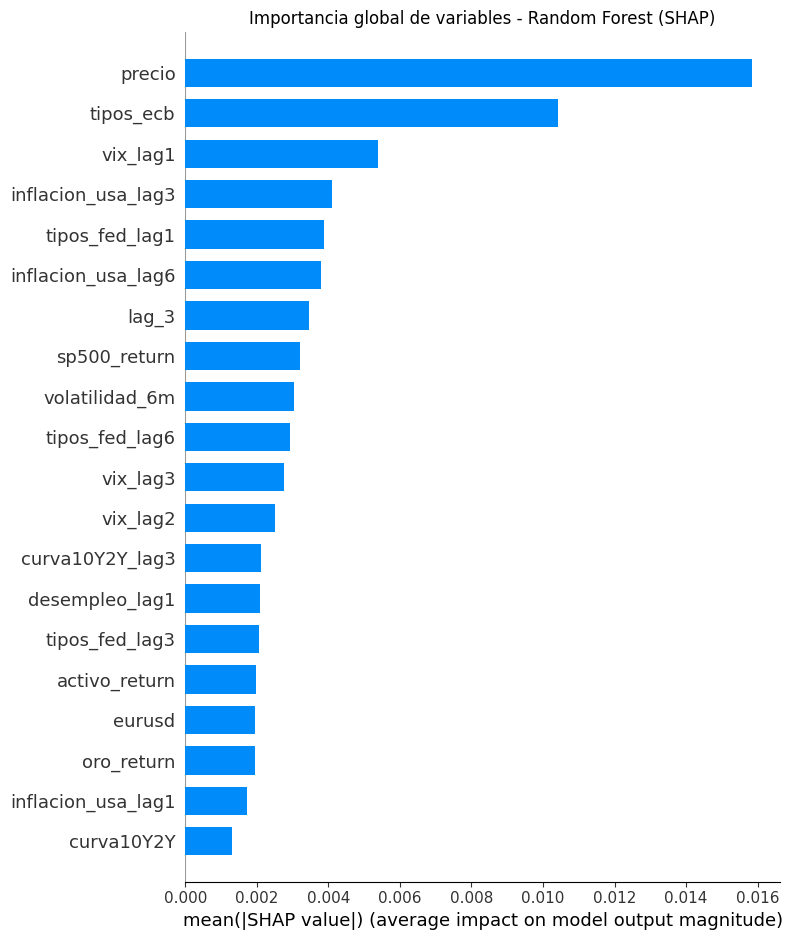

In [42]:
plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values_rf, X_test, plot_type="bar", show=False)
plt.title("Importancia global de variables - Random Forest (SHAP)")
plt.tight_layout()
plt.savefig('shap_importance_rf.png', dpi=150, bbox_inches='tight')
plt.show()

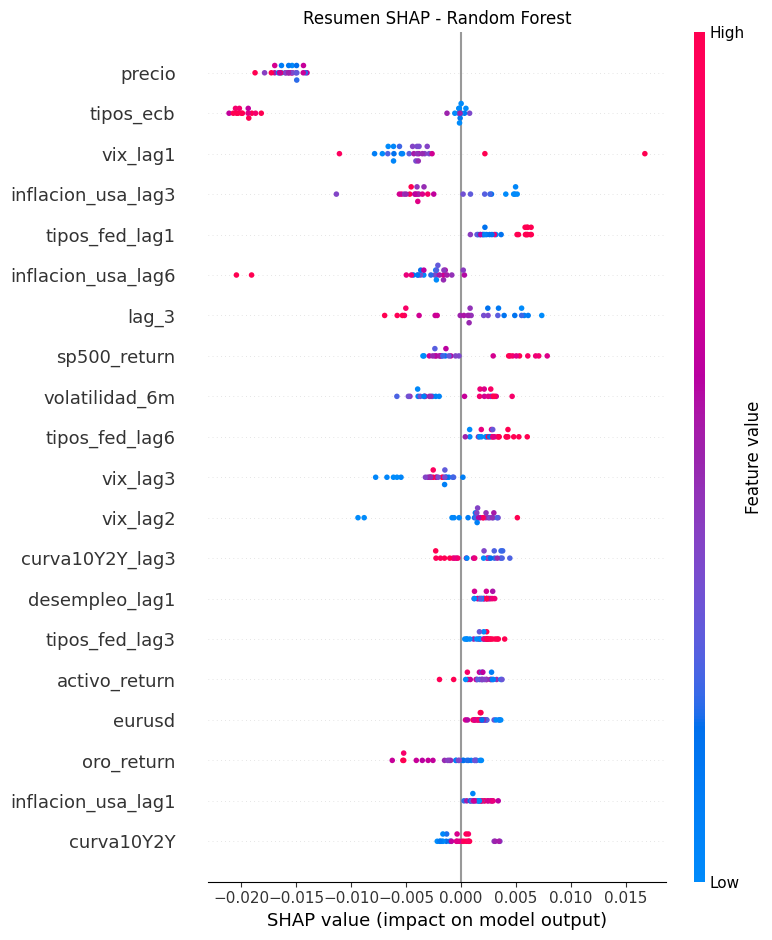

In [43]:
plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values_rf, X_test, show=False)
plt.title("Resumen SHAP - Random Forest")
plt.tight_layout()
plt.savefig('shap_summary_rf.png', dpi=150, bbox_inches='tight')
plt.show()


Variable más importante: precio


<Figure size 1000x600 with 0 Axes>

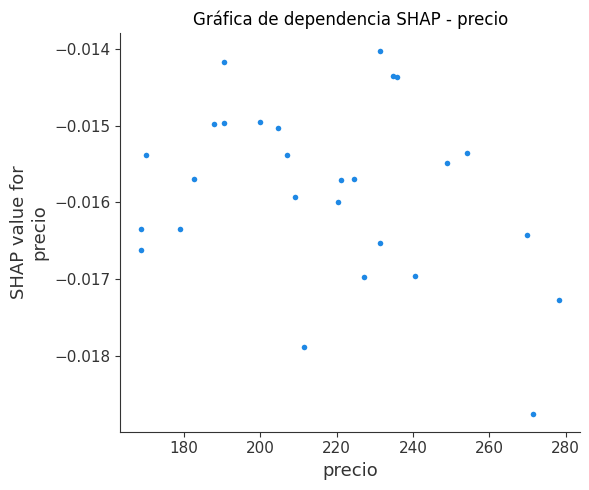

In [44]:
mean_abs_shap = np.abs(shap_values_rf).mean(axis=0)
feature_names = X_test.columns
most_important_idx = np.argmax(mean_abs_shap)
most_important_feature = feature_names[most_important_idx]

print(f"Variable más importante: {most_important_feature}")

plt.figure(figsize=(10, 6))
shap.dependence_plot(most_important_idx, shap_values_rf, X_test, 
                     interaction_index=None, show=False)
plt.title(f"Gráfica de dependencia SHAP - {most_important_feature}")
plt.tight_layout()
plt.savefig('shap_dependence_rf.png', dpi=150, bbox_inches='tight')
plt.show()

Forma de shap_values_for_plot: (26,)


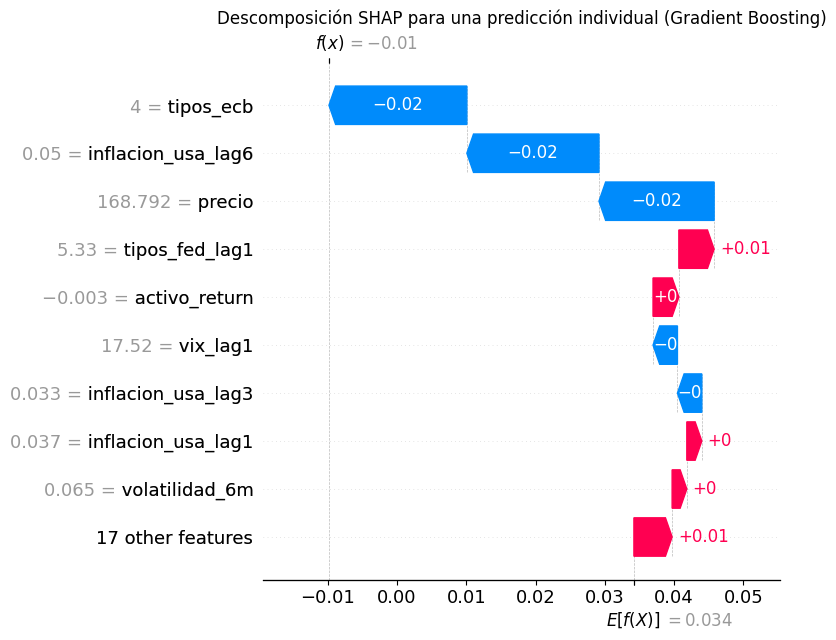

In [46]:
# Elegimos una muestra del conjunto de prueba (la primera)
sample_idx = 0
sample = X_test.iloc[sample_idx:sample_idx+1]

# Calcular valores SHAP para la muestra
shap_values_sample_gb = explainer_rf.shap_values(sample)

# Obtener el valor base como escalar
expected_value_gb = explainer_rf.expected_value
if isinstance(expected_value_gb, np.ndarray):
    expected_value_scalar_gb = expected_value_gb[0]
else:
    expected_value_scalar_gb = expected_value_gb

# Aplanar el array si es necesario
if len(shap_values_sample_gb.shape) > 1:
    shap_values_for_plot_gb = shap_values_sample_gb.flatten()
else:
    shap_values_for_plot_gb = shap_values_sample_gb

print(f"Forma de shap_values_for_plot: {shap_values_for_plot_gb.shape}")

# Crear el objeto Explanation
explanation_rf = shap.Explanation(
    values=shap_values_for_plot_gb,
    base_values=expected_value_scalar_gb,
    data=sample.iloc[0].values,
    feature_names=X_test.columns.tolist()
)

# Generar el waterfall plot
plt.figure(figsize=(12, 6))
shap.waterfall_plot(explanation_rf, show=False)
plt.title(f"Descomposición SHAP para una predicción individual (Gradient Boosting)")
plt.tight_layout()
plt.show()

In [ ]:
# 7. Tabla con las variables más importantes (para la memoria)
importance_df = pd.DataFrame({
    'Variable': feature_names,
    'Importancia_SHAP': mean_abs_shap
}).sort_values('Importancia_SHAP', ascending=False)

print("\nVARIABLES MÁS IMPORTANTES")
print(importance_df.head(10).to_string(index=False))


=== TOP 10 VARIABLES MÁS IMPORTANTES (SHAP) ===
          Variable  Importancia_SHAP
            precio          0.015835
         tipos_ecb          0.010428
          vix_lag1          0.005395
inflacion_usa_lag3          0.004099
    tipos_fed_lag1          0.003865
inflacion_usa_lag6          0.003796
             lag_3          0.003464
      sp500_return          0.003211
    volatilidad_6m          0.003032
    tipos_fed_lag6          0.002922


<Figure size 1000x600 with 0 Axes>

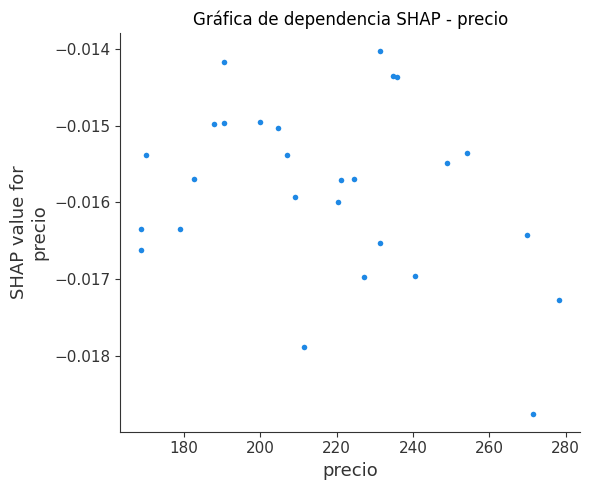

<Figure size 1000x600 with 0 Axes>

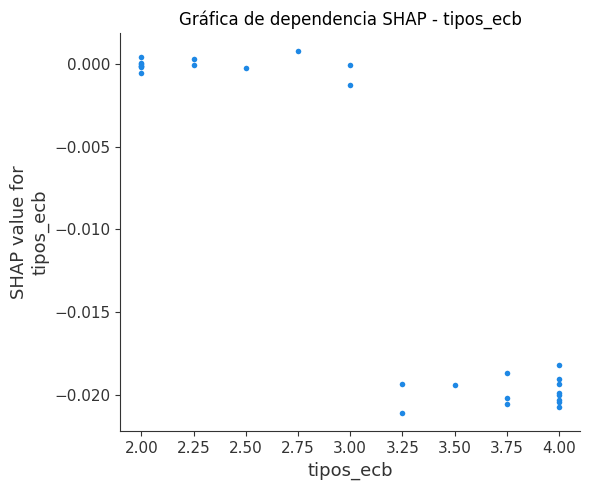

<Figure size 1000x600 with 0 Axes>

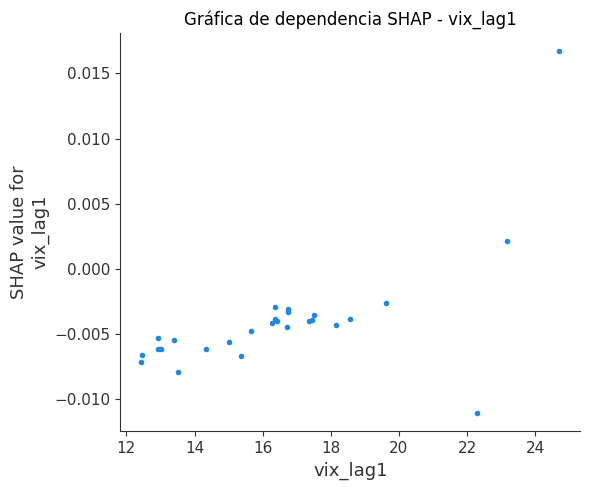

In [48]:
top_3_features = importance_df.head(3)['Variable'].values

for i, feature in enumerate(top_3_features):
    feature_idx = X_test.columns.get_loc(feature)
    plt.figure(figsize=(10, 6))
    shap.dependence_plot(feature_idx, shap_values_rf, X_test, 
                         interaction_index=None, show=False)
    plt.title(f"Gráfica de dependencia SHAP - {feature}")
    plt.tight_layout()
    plt.savefig(f'shap_dependence_{feature}_rf.png', dpi=150, bbox_inches='tight')
    plt.show()

In [49]:
feature_names = X_train.columns.tolist()

# Crear el explainer LIME (tabular)
explainer_lime_rf = lime.lime_tabular.LimeTabularExplainer(
    training_data=np.array(X_train),
    feature_names=feature_names,
    mode='regression',  # Es un problema de regresión
    random_state=42,
    verbose=False
)

In [50]:
sample_idx = 0
sample = X_test.iloc[sample_idx:sample_idx+1]

print(f"Muestra seleccionada (índice {sample_idx}):")
print(f"Valor real: {y_test.iloc[sample_idx]:.4f}")
print(f"Predicción del modelo: {best_rf.predict(sample)[0]:.4f}")

Muestra seleccionada (índice 0):
Valor real: 0.1123
Predicción del modelo: -0.0098


In [51]:
exp_lime_rf = explainer_lime_rf.explain_instance(
    data_row=sample.values[0],
    predict_fn=best_rf.predict,
    num_features=10,  # Mostrar las 10 variables más importantes
    num_samples=5000
)

c:\Users\34620\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(


In [ ]:
print("\nEXPLICACIÓN LIME PARA RANDOM FOREST")
print(exp_lime_rf.as_list())



=== EXPLICACIÓN LIME PARA RANDOM FOREST ===
[('precio > 31.96', -0.013817291561480392), ('inflacion_usa_lag6 > 0.03', -0.008660802113533811), ('16.38 < vix_lag1 <= 22.16', -0.006701988851460934), ('oro_return > 0.03', -0.004880833625851977), ('inflacion_usa_lag1 > 0.03', -0.004216742171081711), ('sp500_return <= -0.02', -0.004089480714007385), ('0.06 < volatilidad_6m <= 0.08', 0.0039078911273640335), ('desempleo_lag1 <= 4.70', 0.0031035430763092656), ('inflacion_usa_lag3 > 0.03', -0.002980699031058133), ('-0.03 < lag_3 <= 0.04', 0.002114962523891062)]


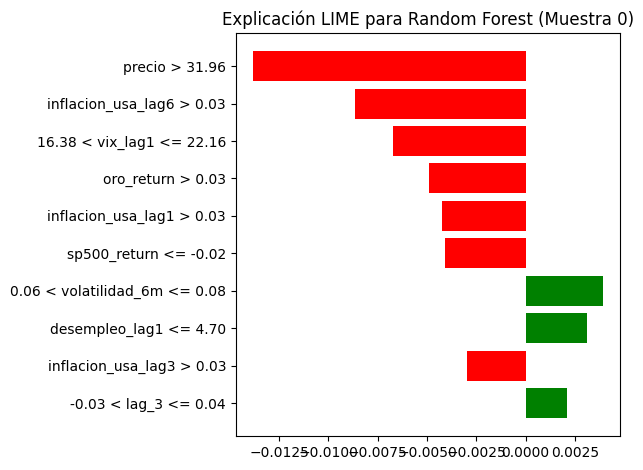

In [53]:
# La figura se guardará como 'lime_rf.png'
fig = exp_lime_rf.as_pyplot_figure()
plt.title(f"Explicación LIME para Random Forest (Muestra {sample_idx})")
plt.tight_layout()
plt.savefig('lime_rf.png', dpi=150, bbox_inches='tight')
plt.show()
